## Fruit Image Classification

Data source: https://www.kaggle.com/datasets/moltean/fruits/code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import PIL

import os
import pathlib

In [2]:
train_dir = pathlib.Path('archive/Training')
test_dir = pathlib.Path('archive/Test')

In [3]:
image_count = len(list(train_dir.glob('*/*.jpg')))

In [4]:
image_count

137932

### Visualization

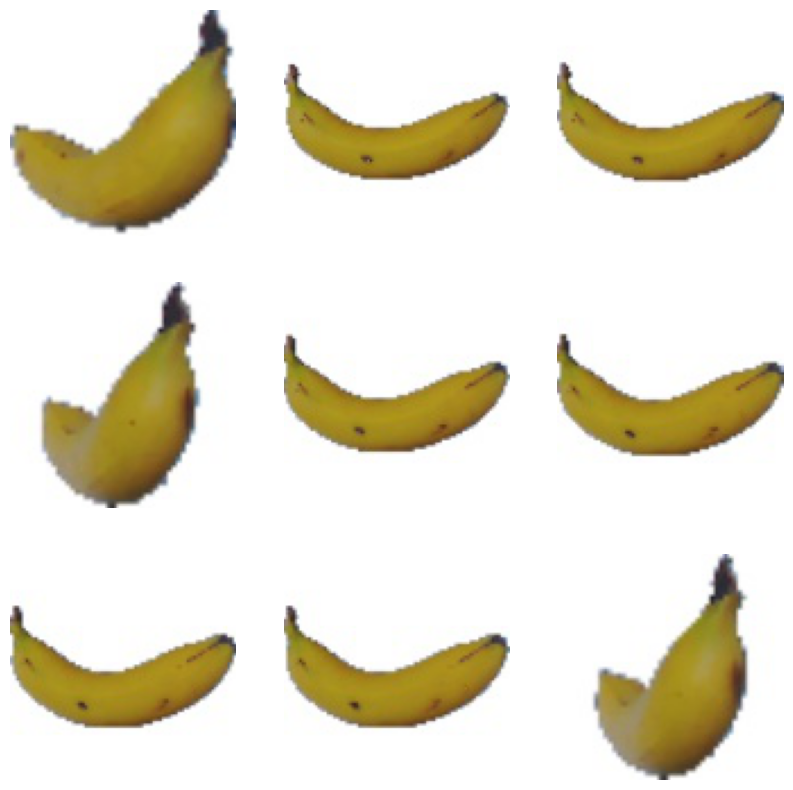

In [5]:
fruits = list(train_dir.glob("Banana 1/*.jpg"))

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = PIL.Image.open(str(fruits[i]))
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [6]:
batch_size = 32
img_height = 100
img_width = 100

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 137932 files belonging to 261 classes.
Using 110346 files for training.
Found 137932 files belonging to 261 classes.
Using 27586 files for validation.


In [8]:
class_names = train_ds.class_names
num_classes = len(class_names)

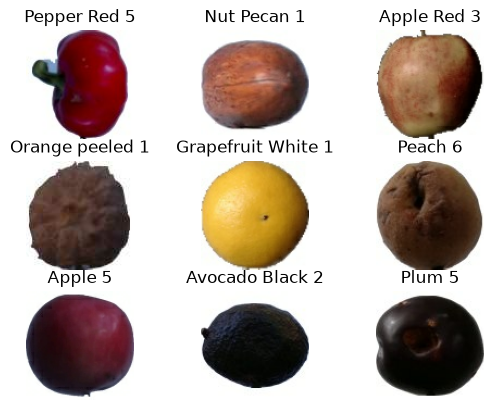

In [9]:
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.show()

### Preprocessing/Setting up Base Model

In [10]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2)
])

In [12]:
preprocess_input = tf.keras.applications.resnet.preprocess_input

In [13]:
base_model = tf.keras.applications.resnet.ResNet50(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

In [14]:
base_model.trainable=False

In [18]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes)

### Building the Model

In [19]:
inputs = tf.keras.layers.Input(shape=(100,100,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [23]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

### Training the model

In [25]:
model.evaluate(val_ds)

863/863 ━━━━━━━━━━━━━━━━━━━━ 1082s 1s/step - accuracy: 0.0029 - loss: 7.0317


[7.031676292419434, 0.002863771514967084]

In [27]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential (Sequential)       │ (None, 100, 100, 3)       │               0 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_3 (GetItem)          │ (None, 100, 100)          │               0 │ sequential[2][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_4 (GetItem)          │ (None, 100, 100)          │               0 │ sequential[2][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_5 (GetItem)          │ (None, 100, 100)          │               0 │ sequential[2][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack_1 (Stack)               │ (None, 100, 100, 3)       │               0 │ get_item_3[0][0],          │
│                               │                           │                 │ get_item_4[0][0],          │
│                               │                           │                 │ get_item_5[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 100, 3)       │               0 │ stack_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 4, 4, 2048)        │      23,587,712 │ add_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 2048)              │               0 │ resnet50[1][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 261)               │         534,789 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 25,192,081 (96.10 MB)

 Trainable params: 534,789 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,069,580 (4.08 MB)

In [ ]:
epochs = 10

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

Epoch 1/10
 598/3449 ━━━━━━━━━━━━━━━━━━━━ 1:03:11 1s/step - accuracy: 0.7099 - loss: 1.2480

KeyboardInterrupt: 